# ScamSense — 04: Exploratory Data Analysis (EDA)

**Purpose:** Understand the full ScamSense dataset before modelling. Analyse class distribution, language coverage, message length, scam type breakdown, token frequency, and data quality. All plots saved to `reports/figures/` for use in the FPR and Power BI dashboard.

**Input:** `data/processed/scamsense_full_dataset.csv`  
**Output:** PNG figures in `reports/figures/`

| Cell | Description |
|---|---|
| 1 | Setup, imports, load dataset |
| 2 | Dataset overview and schema check |
| 3 | Class distribution (overall and per language) |
| 4 | Language distribution |
| 5 | Scam type breakdown |
| 6 | Message length analysis |
| 7 | Token frequency — top words per language |
| 8 | Source breakdown |
| 9 | Data quality checks |
| 10 | Save EDA summary stats for FPR |

In [1]:
# =============================================================================
# CELL 1: Setup, imports, load dataset
# -----------------------------------------------------------------------------
# Mount Drive and set working directory first if not already done.
# Load the full balanced dataset produced by notebook 03.
# =============================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
import warnings
warnings.filterwarnings('ignore')

REPO = '/content/drive/MyDrive/ScamSense'
os.chdir(REPO)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

# Plot style
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})
PALETTE = {
    'en':       '#2196F3',
    'singlish': '#FF9800',
    'ms':       '#4CAF50',
    'ta':       '#9C27B0',
    'zh':       '#F44336',
}
SCAM_COLOR = '#E53935'
HAM_COLOR  = '#43A047'

FIGURES_DIR = f'{REPO}/reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(
    f'{REPO}/data/processed/scamsense_full_dataset.csv',
    encoding='utf-8-sig',
)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Mounted at /content/drive
Dataset loaded: 129,134 rows x 5 columns
Columns: ['text', 'label', 'language', 'source', 'strat_key']


In [2]:
# =============================================================================
# CELL 2: Dataset overview and schema check
# -----------------------------------------------------------------------------
# Confirms schema, null counts, data types, and prints a sample from each
# language to visually verify encoding is correct.
# =============================================================================
print('=== SCHEMA ===')
print(df.dtypes)
print()

print('=== NULL COUNTS ===')
print(df.isnull().sum())
print()

print('=== LABEL VALUES ===')
print(df['label'].value_counts())
print()

print('=== LANGUAGE VALUES ===')
print(df['language'].value_counts())
print()

print('=== ONE SAMPLE PER LANGUAGE ===')
for lang in df['language'].unique():
    sample = df[df['language'] == lang]['text'].iloc[0]
    print(f'[{lang}] {sample[:120]}')
    print()

=== SCHEMA ===
text         object
label         int64
language     object
source       object
strat_key    object
dtype: object

=== NULL COUNTS ===
text         0
label        0
language     0
source       0
strat_key    0
dtype: int64

=== LABEL VALUES ===
label
0    64567
1    64567
Name: count, dtype: int64

=== LANGUAGE VALUES ===
language
en          98310
ta           9522
zh           7646
singlish     7408
ms           6248
Name: count, dtype: int64

=== ONE SAMPLE PER LANGUAGE ===
[en] [Raleigh, NC] Fundraising Consultant Position: Fundraising ConsultantLocation: Raleigh, NC Reports to: Director Of Sales

[singlish] WhatsApp job sia, do task earn commission, SGD 2000 daily.

[zh] 借款的许可证,150SGD的贷款,利息低,你的账户将被终止.

[ms] Penghantaran yang tidak dibenarkan ke akaun UOB anda.

[ta] ரஃப்வேல் கோர்ரியா டெல்காடோ (Rafael Correa Delgado) (பிறப்பு 6 ஏப்ரல் 1963) ஈக்குடோர் நாட்டின் ஜனதிபதியாக தேர்தெடுக்கப்பட



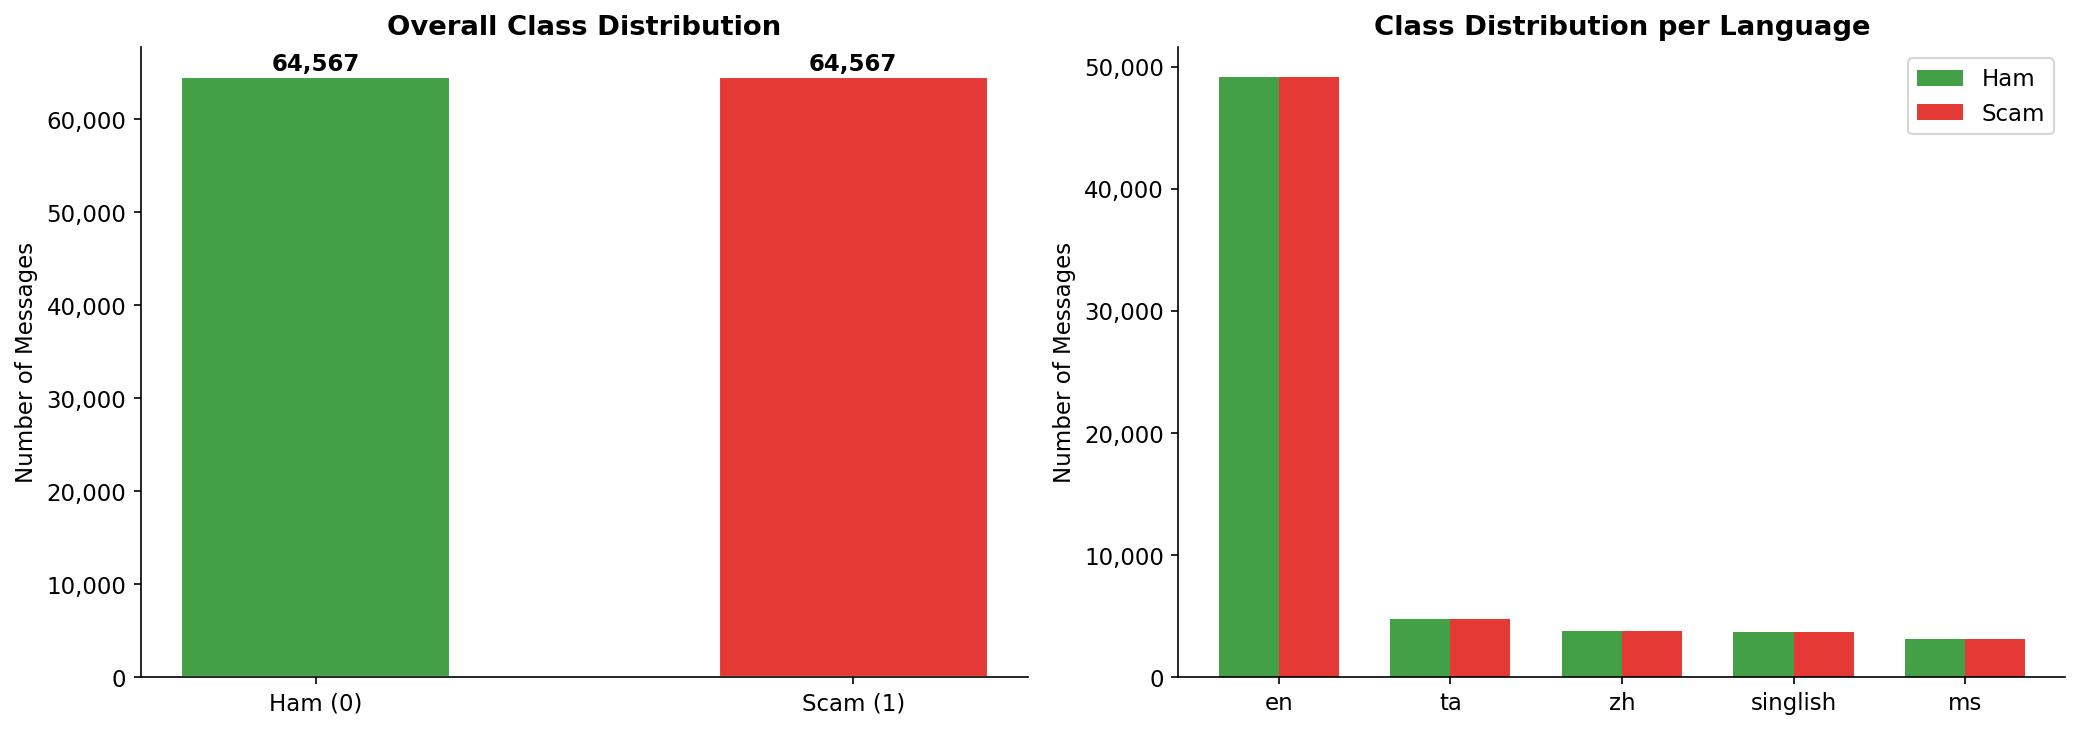

Saved: 01_class_distribution.png


In [3]:
# =============================================================================
# CELL 3: Class distribution — overall and per language
# -----------------------------------------------------------------------------
# Two plots:
#   Left:  overall scam vs ham counts
#   Right: per-language scam vs ham counts (stacked bar)
# Confirms the per-language undersampling from notebook 03 worked correctly.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Overall class distribution ---
ax = axes[0]
counts = df['label'].value_counts().sort_index()
bars = ax.bar(
    ['Ham (0)', 'Scam (1)'],
    counts.values,
    color=[HAM_COLOR, SCAM_COLOR],
    width=0.5,
    edgecolor='white',
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Overall Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Messages')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Per-language class distribution ---
ax = axes[1]
lang_label = df.groupby(['language', 'label']).size().unstack(fill_value=0)
lang_label = lang_label.reindex(columns=[0, 1])
lang_order = lang_label.sum(axis=1).sort_values(ascending=False).index
lang_label = lang_label.loc[lang_order]
x = range(len(lang_label))
w = 0.35
ax.bar([i - w/2 for i in x], lang_label[0], width=w, label='Ham', color=HAM_COLOR)
ax.bar([i + w/2 for i in x], lang_label[1], width=w, label='Scam', color=SCAM_COLOR)
ax.set_xticks(list(x))
ax.set_xticklabels(lang_label.index)
ax.set_title('Class Distribution per Language', fontweight='bold')
ax.set_ylabel('Number of Messages')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

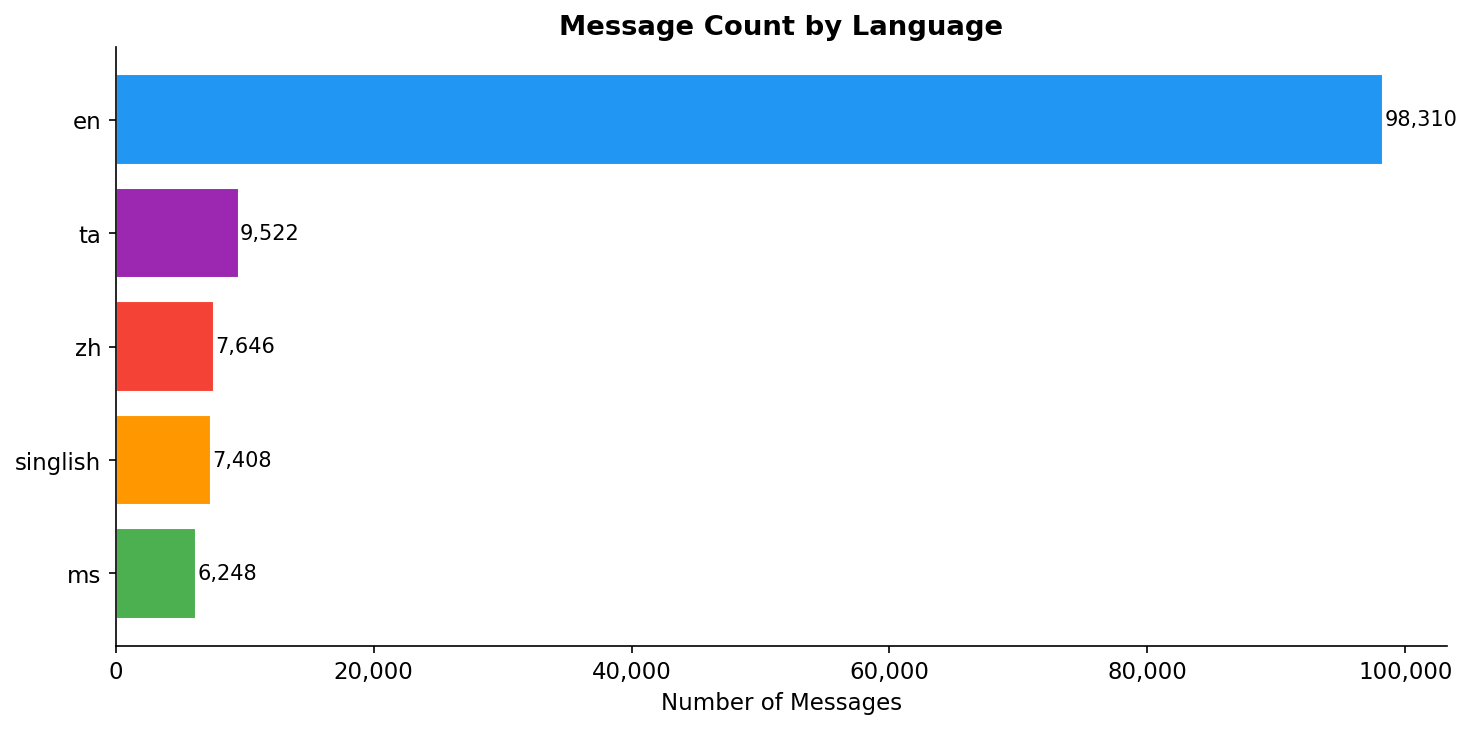

Saved: 02_language_distribution.png

Language share:
  en        : 98,310  (76.1%)
  ta        :  9,522  (7.4%)
  zh        :  7,646  (5.9%)
  singlish  :  7,408  (5.7%)
  ms        :  6,248  (4.8%)


In [4]:
# =============================================================================
# CELL 4: Language distribution
# -----------------------------------------------------------------------------
# Shows the number of messages per language as a horizontal bar chart.
# English dominates due to the phishing email dataset.
# Non-English languages (MS/TA/ZH/Singlish) come from synthetic + Wikipedia + NUS SMS.
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

lang_counts = df['language'].value_counts()
colors = [PALETTE.get(lang, '#607D8B') for lang in lang_counts.index]

bars = ax.barh(lang_counts.index, lang_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, lang_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Messages')
ax.set_title('Message Count by Language', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_language_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 02_language_distribution.png')

# Print percentages
print('\nLanguage share:')
for lang, cnt in lang_counts.items():
    print(f'  {lang:10s}: {cnt:6,}  ({cnt/len(df)*100:.1f}%)')

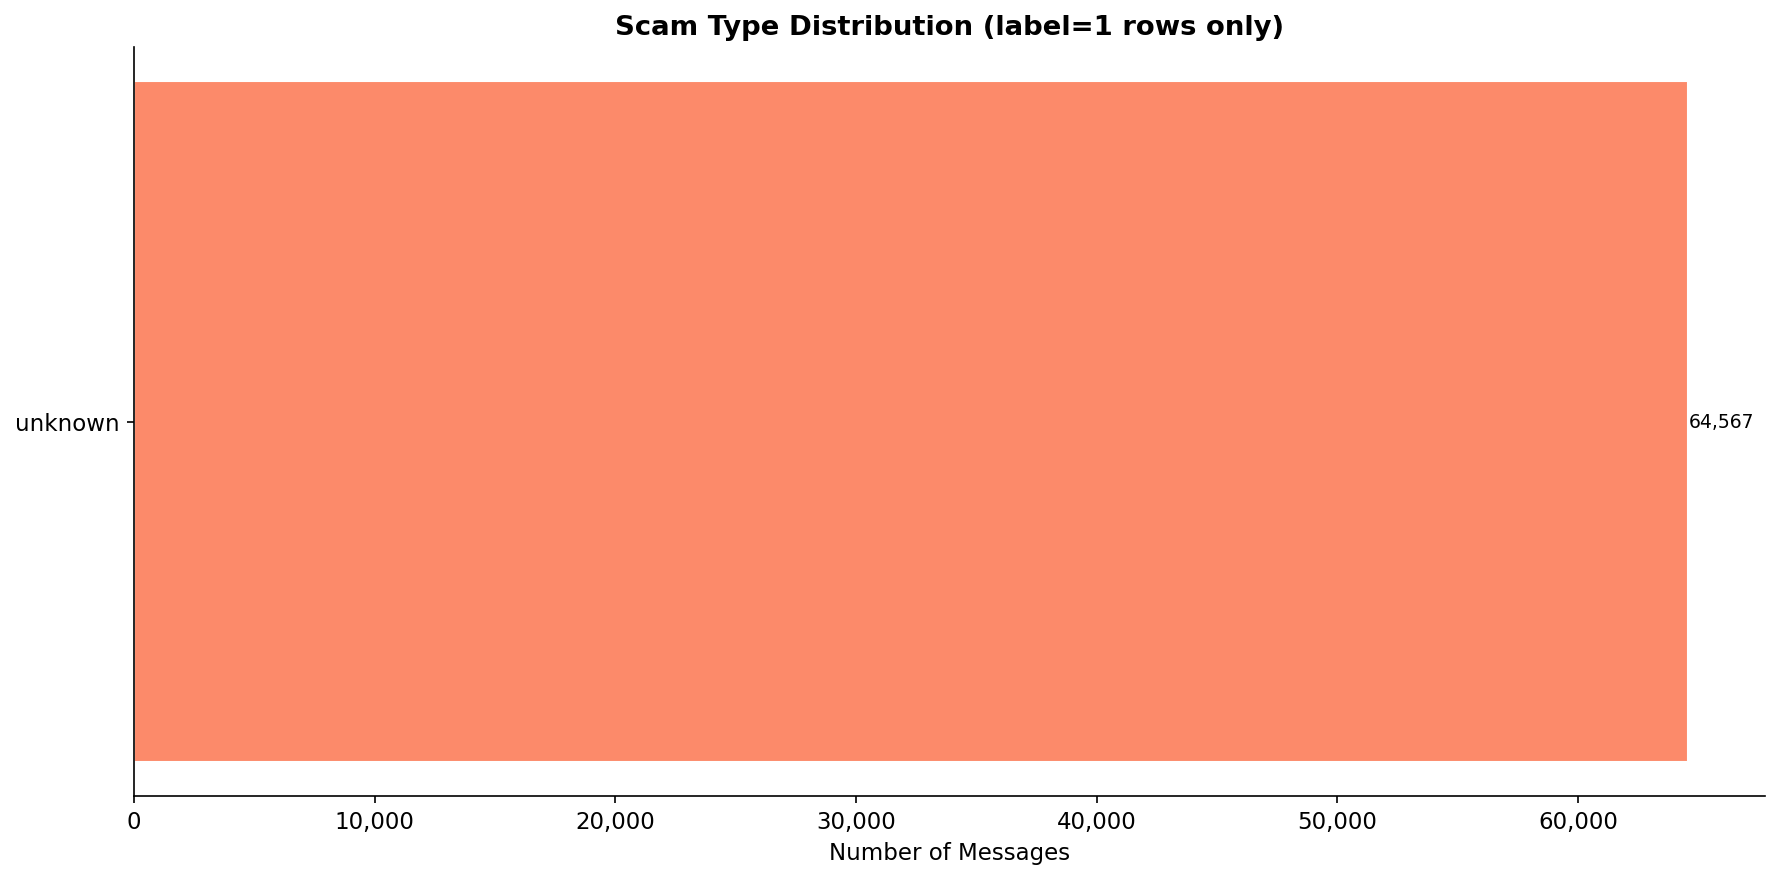

Saved: 03_scam_type_distribution.png


In [5]:
# =============================================================================
# CELL 5: Scam type breakdown
# -----------------------------------------------------------------------------
# scam_type column exists only for synthetic rows and job_postings.
# For phishing email and UCI SMS rows it will be NaN — we label those
# as 'phishing_email' and 'sms_spam' respectively for the plot.
# This shows the taxonomy coverage of the full scam corpus.
# =============================================================================

# Fill missing scam_type based on source
df['scam_type_filled'] = df['scam_type'].copy() if 'scam_type' in df.columns else 'unknown'
if 'scam_type' in df.columns:
    df['scam_type_filled'] = df['scam_type'].fillna(
        df['source'].map(lambda s: (
            'phishing_email' if 'phishing' in str(s) else
            'sms_spam'       if 'uci'      in str(s) else
            'fake_job'       if 'job'      in str(s) else
            'ham'
        ))
    )

# Scam types for scam rows only
df_scam_only = df[df['label'] == 1]
scam_type_counts = df_scam_only['scam_type_filled'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(scam_type_counts)))
bars = ax.barh(scam_type_counts.index, scam_type_counts.values,
               color=colors, edgecolor='white')
for bar, val in zip(bars, scam_type_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of Messages')
ax.set_title('Scam Type Distribution (label=1 rows only)', fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_scam_type_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 03_scam_type_distribution.png')

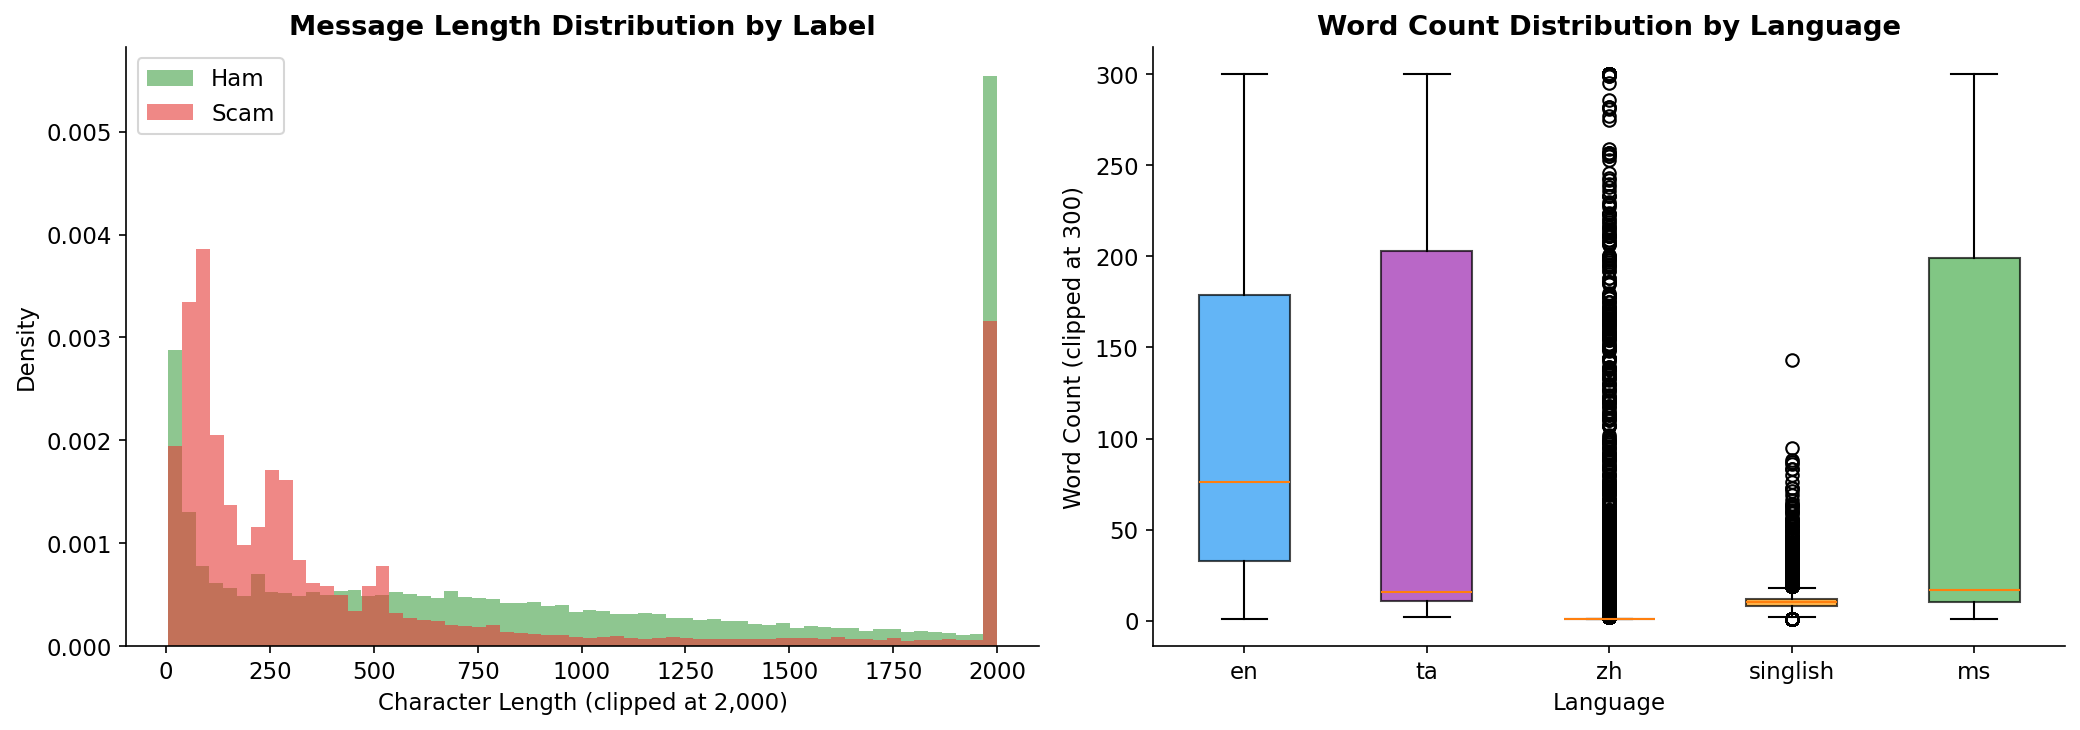

Saved: 04_message_length.png

=== MESSAGE LENGTH STATISTICS ===
      char_len                                                         \
         count    mean      std  min    25%    50%     75%        max   
label                                                                   
0      64567.0  1586.2   3984.9  5.0  250.0  745.0  1536.0   160318.0   
1      64567.0   739.5  17279.4  6.0   89.0  246.0   569.0  4279526.0   

      word_count                                                   
           count   mean    std  min   25%    50%    75%       max  
label                                                              
0        64567.0  202.4  494.8  1.0  35.0  101.0  206.0   23359.0  
1        64567.0   85.5  487.6  1.0  12.0   33.0   84.0  107710.0  


In [6]:
# =============================================================================
# CELL 6: Message length analysis
# -----------------------------------------------------------------------------
# Computes character length and word count per message.
# Plots:
#   1. Character length distribution by label (scam vs ham)
#   2. Word count distribution by language
#   3. Summary statistics table
#
# Phishing emails are long (hundreds of words).
# SMS and synthetic messages are short (5-50 words).
# This length difference is itself a signal for the classifier.
# =============================================================================
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Character length by label ---
ax = axes[0]
for label, color, name in [(0, HAM_COLOR, 'Ham'), (1, SCAM_COLOR, 'Scam')]:
    data = df[df['label'] == label]['char_len'].clip(upper=2000)
    ax.hist(data, bins=60, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('Character Length (clipped at 2,000)')
ax.set_ylabel('Density')
ax.set_title('Message Length Distribution by Label', fontweight='bold')
ax.legend()

# --- Word count by language (box plot) ---
ax = axes[1]
lang_order = df['language'].value_counts().index.tolist()
data_by_lang = [df[df['language'] == lang]['word_count'].clip(upper=300).values
                for lang in lang_order]
bp = ax.boxplot(data_by_lang, labels=lang_order, patch_artist=True, notch=False)
for patch, lang in zip(bp['boxes'], lang_order):
    patch.set_facecolor(PALETTE.get(lang, '#607D8B'))
    patch.set_alpha(0.7)
ax.set_xlabel('Language')
ax.set_ylabel('Word Count (clipped at 300)')
ax.set_title('Word Count Distribution by Language', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_message_length.png', bbox_inches='tight')
plt.show()
print('Saved: 04_message_length.png')

# Summary statistics
print('\n=== MESSAGE LENGTH STATISTICS ===')
print(df.groupby('label')[['char_len', 'word_count']].describe().round(1))

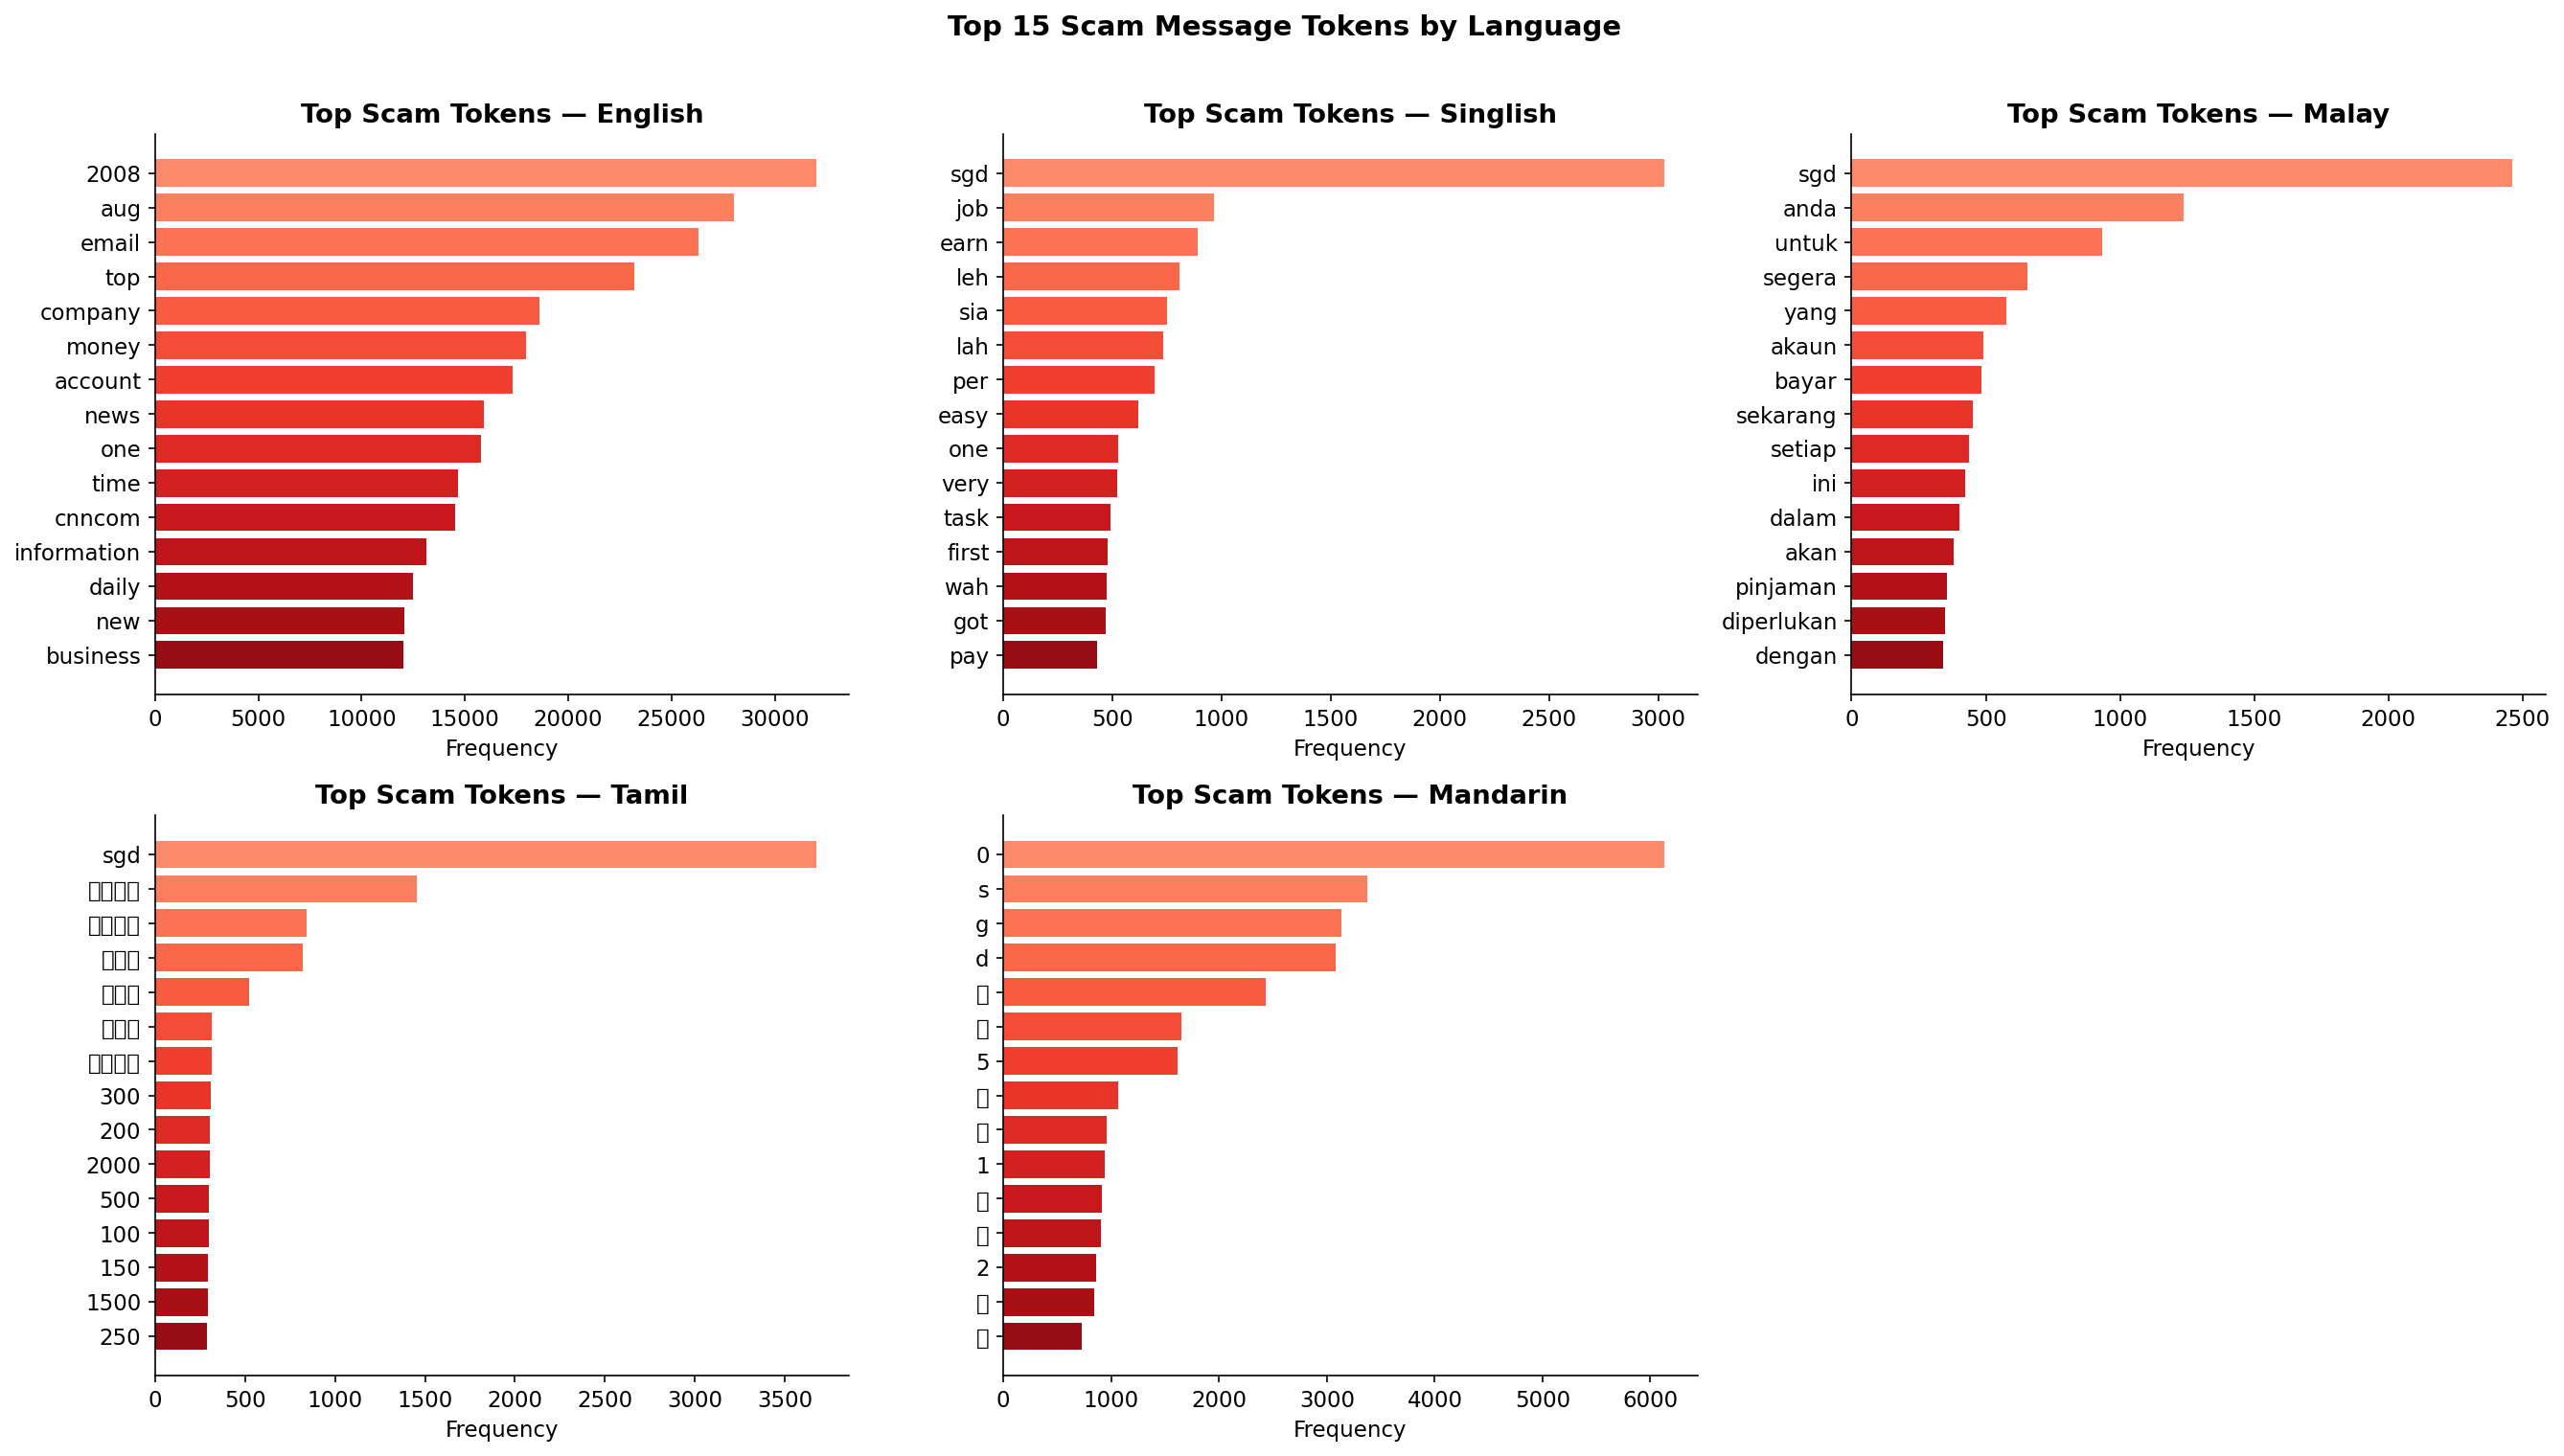

Saved: 05_token_frequency.png


In [7]:
# =============================================================================
# CELL 7: Token frequency — top words per language
# -----------------------------------------------------------------------------
# Shows the 15 most frequent tokens in scam messages for each language.
# English uses simple whitespace tokenisation.
# For CJK (Mandarin), character-level splitting is used as a proxy
# since word boundaries require a dedicated tokeniser.
#
# Common scam signal words (urgent, verify, SGD, transfer) should appear
# prominently in EN and Singlish — this confirms the synthetic templates
# are generating relevant vocabulary.
# =============================================================================

STOPWORDS_EN = {
    'the','a','an','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','could',
    'should','may','might','shall','can','to','of','in','for',
    'on','with','at','by','from','as','into','through','and',
    'or','but','if','then','that','this','it','its','your',
    'our','their','my','we','you','i','he','she','they','not',
    'no','so','up','out','about','all','get','now','just','more',
    'please','dear','hi','hello','nan',
}

def top_tokens(texts, n=15, cjk=False):
    tokens = []
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
        text = re.sub(r'[^\w\s]', ' ', text)          # remove punctuation
        if cjk:
            tokens.extend(list(text.replace(' ', '')))
        else:
            words = text.split()
            tokens.extend([w for w in words if w not in STOPWORDS_EN and len(w) > 2])
    return Counter(tokens).most_common(n)

LANG_CONFIG = [
    ('en',       'English',   False),
    ('singlish', 'Singlish',  False),
    ('ms',       'Malay',     False),
    ('ta',       'Tamil',     False),
    ('zh',       'Mandarin',  True),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (lang, lang_name, cjk) in enumerate(LANG_CONFIG):
    scam_texts = df[(df['language'] == lang) & (df['label'] == 1)]['text']
    top = top_tokens(scam_texts, n=15, cjk=cjk)
    if not top:
        continue
    words, counts = zip(*top)
    ax = axes[idx]
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(words)))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=colors[::-1])
    ax.set_title(f'Top Scam Tokens — {lang_name}', fontweight='bold')
    ax.set_xlabel('Frequency')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Top 15 Scam Message Tokens by Language', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_token_frequency.png', bbox_inches='tight')
plt.show()
print('Saved: 05_token_frequency.png')

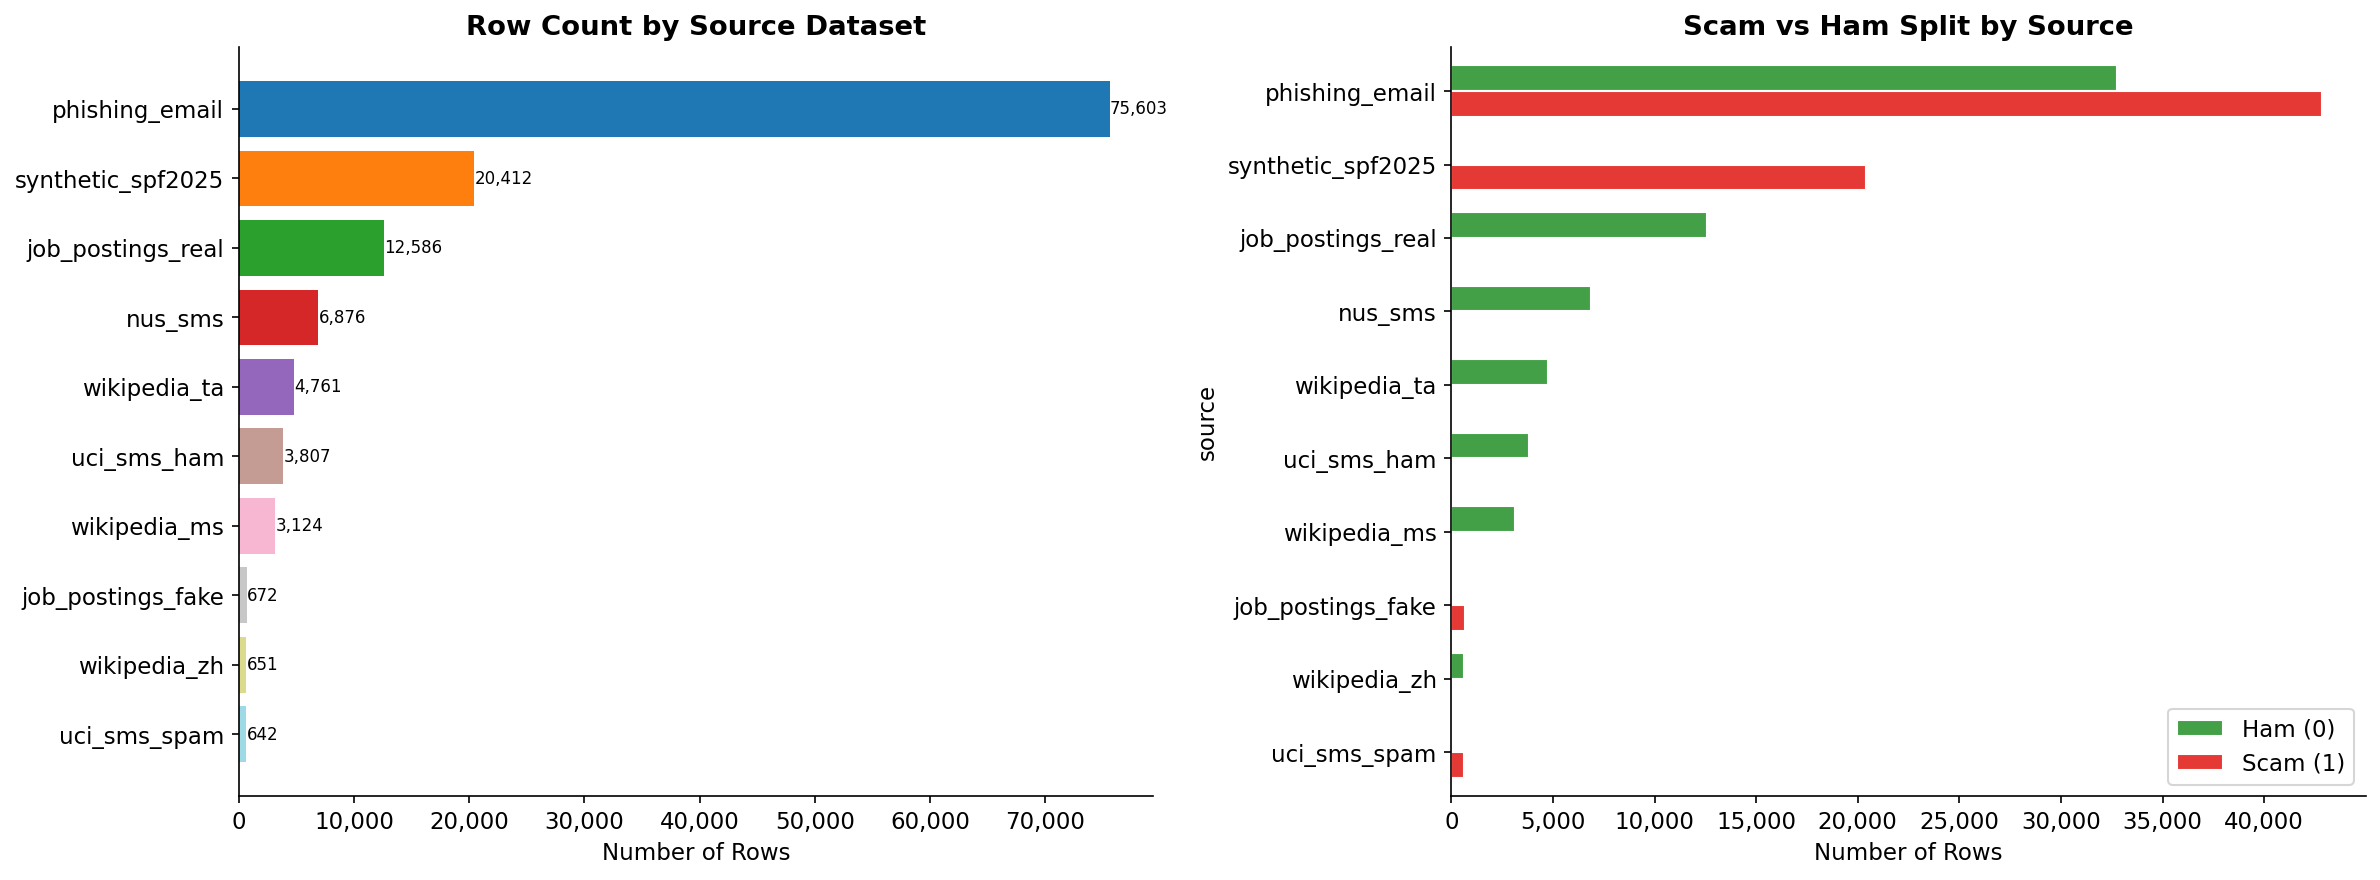

Saved: 06_source_breakdown.png


In [8]:
# =============================================================================
# CELL 8: Source breakdown
# -----------------------------------------------------------------------------
# Shows how many rows came from each original dataset.
# Useful for the FPR methodology section to justify dataset composition.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All sources
ax = axes[0]
src_counts = df['source'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(src_counts)))
bars = ax.barh(src_counts.index, src_counts.values, color=colors)
for bar, val in zip(bars, src_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
ax.set_title('Row Count by Source Dataset', fontweight='bold')
ax.set_xlabel('Number of Rows')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Scam vs ham split by source
ax = axes[1]
src_label = df.groupby(['source', 'label']).size().unstack(fill_value=0)
src_label = src_label.loc[src_counts.index]  # same order
src_label.plot(kind='barh', ax=ax, color=[HAM_COLOR, SCAM_COLOR],
               width=0.7, edgecolor='white')
ax.set_title('Scam vs Ham Split by Source', fontweight='bold')
ax.set_xlabel('Number of Rows')
ax.legend(['Ham (0)', 'Scam (1)'])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_source_breakdown.png', bbox_inches='tight')
plt.show()
print('Saved: 06_source_breakdown.png')

In [9]:
# =============================================================================
# CELL 9: Data quality checks
# -----------------------------------------------------------------------------
# Checks for issues that could affect model training:
#   1. Duplicate texts across different labels (same text labelled both 0 and 1)
#   2. Very short messages (under 10 chars) — likely noise
#   3. Very long messages (over 5,000 chars) — may need truncation
#   4. Non-UTF-8 characters or encoding artifacts
# =============================================================================

print('=== DATA QUALITY REPORT ===')
print()

# 1. Label conflicts — same text with both labels
label_conflicts = (
    df.groupby('text')['label']
    .nunique()
    .reset_index()
    .query('label > 1')
)
print(f'1. Label conflicts (same text, different labels): {len(label_conflicts):,}')
if len(label_conflicts) > 0:
    print('   Sample conflicts:')
    sample_texts = label_conflicts['text'].head(3).tolist()
    for t in sample_texts:
        print(f'   [{t[:60]}...]')

# 2. Very short messages
short = df[df['char_len'] < 10]
print(f'2. Very short messages (< 10 chars): {len(short):,}')
if len(short) > 0:
    print(f'   Sample: {short["text"].head(5).tolist()}')

# 3. Very long messages
long_msgs = df[df['char_len'] > 5000]
print(f'3. Very long messages (> 5,000 chars): {len(long_msgs):,}')
print(f'   Max length: {df["char_len"].max():,} chars')
print(f'   99th percentile: {df["char_len"].quantile(0.99):.0f} chars')

# 4. Rows where text is just 'nan' string
nan_strings = df[df['text'].str.lower() == 'nan']
print(f'4. Rows where text is literal "nan": {len(nan_strings):,}')

print()
print('=== RECOMMENDATIONS ===')
if len(label_conflicts) > 0:
    print('⚠ Drop or manually review label conflicts before training.')
if len(short) > 0:
    print('⚠ Consider dropping messages under 10 chars — likely noise.')
if len(long_msgs) > 0:
    print('ℹ Long messages will be truncated to 512 tokens by the tokeniser — expected behaviour.')
if len(nan_strings) > 0:
    print('⚠ Drop rows where text is literal "nan".')
print()
print('Note: XLM-RoBERTa max input length is 512 tokens.')
print(f'Messages over ~400 words will be truncated during tokenisation.')

=== DATA QUALITY REPORT ===

1. Label conflicts (same text, different labels): 0
2. Very short messages (< 10 chars): 1,267
   Sample: ['I know', '将来你想干嘛', 'On it', '你住在哪儿呀', '我弟给你发短信了？']
3. Very long messages (> 5,000 chars): 4,265
   Max length: 4,279,526 chars
   99th percentile: 10471 chars
4. Rows where text is literal "nan": 0

=== RECOMMENDATIONS ===
⚠ Consider dropping messages under 10 chars — likely noise.
ℹ Long messages will be truncated to 512 tokens by the tokeniser — expected behaviour.

Note: XLM-RoBERTa max input length is 512 tokens.
Messages over ~400 words will be truncated during tokenisation.


In [10]:
# =============================================================================
# CELL 10: Save EDA summary stats for FPR
# -----------------------------------------------------------------------------
# Saves a clean summary CSV with key statistics for each language.
# This table can be directly cited in the FPR methodology section.
# Also prints the complete dataset composition table.
# =============================================================================

summary_rows = []
for lang in df['language'].unique():
    df_lang = df[df['language'] == lang]
    summary_rows.append({
        'language':       lang,
        'total_rows':     len(df_lang),
        'scam_rows':      int((df_lang['label'] == 1).sum()),
        'ham_rows':       int((df_lang['label'] == 0).sum()),
        'balance_ratio':  round((df_lang['label'] == 1).sum() / len(df_lang), 3),
        'avg_char_len':   round(df_lang['char_len'].mean(), 1),
        'median_char_len':round(df_lang['char_len'].median(), 1),
        'avg_word_count': round(df_lang['word_count'].mean(), 1),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('total_rows', ascending=False)

# Add totals row
totals = {
    'language':        'TOTAL',
    'total_rows':      len(df),
    'scam_rows':       int((df['label'] == 1).sum()),
    'ham_rows':        int((df['label'] == 0).sum()),
    'balance_ratio':   round((df['label'] == 1).sum() / len(df), 3),
    'avg_char_len':    round(df['char_len'].mean(), 1),
    'median_char_len': round(df['char_len'].median(), 1),
    'avg_word_count':  round(df['word_count'].mean(), 1),
}
df_summary = pd.concat([df_summary, pd.DataFrame([totals])], ignore_index=True)

# Save
summary_path = f'{REPO}/reports/eda_summary.csv'
df_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
print('=== EDA SUMMARY TABLE ===')
print(df_summary.to_string(index=False))
print(f'\nSaved to: {summary_path}')

print('\n=== FIGURES SAVED TO reports/figures/ ===')
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f'  {f}')

print('\n✅ Notebook 04 complete. Proceed to notebook 05 (Modelling).')

=== EDA SUMMARY TABLE ===
language  total_rows  scam_rows  ham_rows  balance_ratio  avg_char_len  median_char_len  avg_word_count
      en       98310      49155     49155            0.5        1159.9            533.0           146.9
      ta        9522       4761      4761            0.5        2044.4            145.0           225.3
      zh        7646       3823      3823            0.5         361.2             20.0            11.6
singlish        7408       3704      3704            0.5          55.6             54.0            10.7
      ms        6248       3124      3124            0.5        2159.7            124.0           294.4
   TOTAL      129134      64567     64567            0.5        1162.9            408.0           144.0

Saved to: /content/drive/MyDrive/ScamSense/reports/eda_summary.csv

=== FIGURES SAVED TO reports/figures/ ===
  01_class_distribution.png
  02_language_distribution.png
  03_scam_type_distribution.png
  04_message_length.png
  05_token_frequency